# Práctica 1A: Cálculo de frecuencias a nivel de un carácter

## Realizado por: Eduardo Alanís García


# Instrucciones

## 1. Preprocesamiento del texto

Crear un notebook para preprocesar el texto y realizar las siguientes operaciones:

- Convertir el texto a **minúsculas**.
- Quitar los **acentos**.
- Eliminar los siguientes caracteres:

  `; : , . \ - " ‘ / ( ) [ ] ¿ ? ¡ ! { } ~ < > | « » - — ’`

- Reemplazar las **tabulaciones** (`\t`) y los **saltos de línea** (`\n`) por un espacio.

## 2. Cálculo de frecuencias e histogramas

Calcular las **frecuencias a nivel de un carácter** de los documentos `text_1.txt` al `text_5.txt`.

Para cada archivo:

1. Preprocesar el texto.
2. Calcular la frecuencia de cada carácter.
3. Ordenar los caracteres de acuerdo con su frecuencia, de **mayor a menor**.
4. Generar un **histograma** con las frecuencias de los caracteres.

Repetir el mismo procedimiento para los archivos `libro_1.txt` y `libro_2.txt`.

### Archivos

- [text_1.txt](https://aulavirtual.infotec.mx/pluginfile.php/159708/mod_assign/intro/text_1.txt?time=1769720645712)
- [text_2.txt](https://aulavirtual.infotec.mx/pluginfile.php/159708/mod_assign/intro/text_2.txt?time=1769720659575)
- [text_3.txt](https://aulavirtual.infotec.mx/pluginfile.php/159708/mod_assign/intro/text_3.txt?time=1769720672169)
- [text_4.txt](https://aulavirtual.infotec.mx/pluginfile.php/159708/mod_assign/intro/text_4.txt?time=1769720696831)
- [text_5.txt](https://aulavirtual.infotec.mx/pluginfile.php/159708/mod_assign/intro/text_5.txt?time=1769720706985)
- [libro_1.txt](https://aulavirtual.infotec.mx/pluginfile.php/159708/mod_assign/intro/libro_1.txt)
- [libro_2.txt](https://aulavirtual.infotec.mx/pluginfile.php/159708/mod_assign/intro/libro_2.txt)

## 3. Evaluación

Contestar la **evaluación de esta práctica** disponible en el Aula Virtual.

# Solución:

### Cargar google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Verificar existencia de los archivos

In [ ]:
direccion = "/content/drive/MyDrive/MCDI-INFOTEC/1. Primer semestre/Manejo y procesamiento de la informacion/Unidad 1/Práctica 1A Cálculo de frecuencias a nivel de un carácter/"

import os
archivos = ["text_1.txt", "text_2.txt", "text_3.txt", "text_4.txt", "text_5.txt","libro_1.txt", "libro_2.txt"]

for archivo in archivos:
  ruta = os.path.join(direccion, archivo)
  print(archivo, "Existe" if os.path.exists(ruta) else "No Existe")


text_1.txt Existe
text_2.txt Existe
text_3.txt Existe
text_4.txt Existe
text_5.txt Existe
libro_1.txt Existe
libro_2.txt Existe


### Función leer archivos

In [ ]:
def leer_archivo(nombre_archivo, direccion = "/content/drive/MyDrive/MCDI-INFOTEC/1. Primer semestre/Manejo y procesamiento de la informacion/Unidad 1/Práctica 1A Cálculo de frecuencias a nivel de un carácter/"):
  ruta = os.path.join(direccion, nombre_archivo)

  with open(ruta, "r", encoding="utf-8") as f:
      texto = f.read()

  return texto

### Función de quitar acentos

In [ ]:
import unicodedata

def remove_accents(input_str):
  nfkd_form = unicodedata.normalize('NFKD', input_str)
  return u"".join([c for c in nfkd_form if not unicodedata.combining(c)])

### Caracteres a eliminar

In [ ]:
caracteres_eliminar = '“;:,.\\"-‘/()[]¿?¡!{}~<>|«»-—’”'

In [ ]:
import re
def preprocesar_texto(texto):
  texto = texto.lower() # Minusculas
  texto = remove_accents(texto) # Acentos
  texto = texto.replace('\t', ' ').replace('\n', ' ') # Tabulaciones y saltos de linea
  for c in caracteres_eliminar:
    #print(c, end=" ")
    texto = texto.replace(c, '')  # Eliminar caracteres mencionados

  #texto = re.sub(r'\s+', ' ', texto).strip()  # Quitar mas de estapacios dobles y inicios final, equivalente a stringr::str_squish() de R
  return texto

### Función calculo de frecuencias

In [ ]:
from collections import Counter
def calcular_frecuencias(texto):
  frecuencias = Counter(texto)
  ordenado = frecuencias.most_common()

  caracteres = []
  valores = []

  for c, f in ordenado:
    if c == ' ':
      caracteres.append('espacio')
    else:
      caracteres.append(c)


    valores.append(f)


  guardar = {"caracteres":caracteres, "valores":valores}


  return guardar

### Generar los resultados

In [ ]:
resultados = {}

for archivo in archivos:
  texto_original =  leer_archivo(nombre_archivo=archivo)
  texto_procesado = preprocesar_texto(texto=texto_original)
  frecuencias = calcular_frecuencias(texto=texto_procesado)

  resultados[archivo] = {
    "texto_original": texto_original,
    "texto_procesado": texto_procesado,
    "frecuencias": frecuencias
  }



### Función general graficas

In [ ]:
import matplotlib.pyplot as plt
def graficar_histograma(resultados, titulo):
  caracteres = resultados[titulo]["frecuencias"]["caracteres"]
  valores = resultados[titulo]["frecuencias"]["valores"]

  plt.figure(figsize=(14, 5))

  barras = plt.bar(caracteres, valores)

  plt.title(titulo)
  plt.xlabel('Caracter')
  plt.ylabel('Frecuencia')
  plt.xticks(rotation=90)

  # Mostrar el valor encima de cada barra
  plt.bar_label(barras, padding=3)

  plt.tight_layout()
  plt.show()

### Graficas

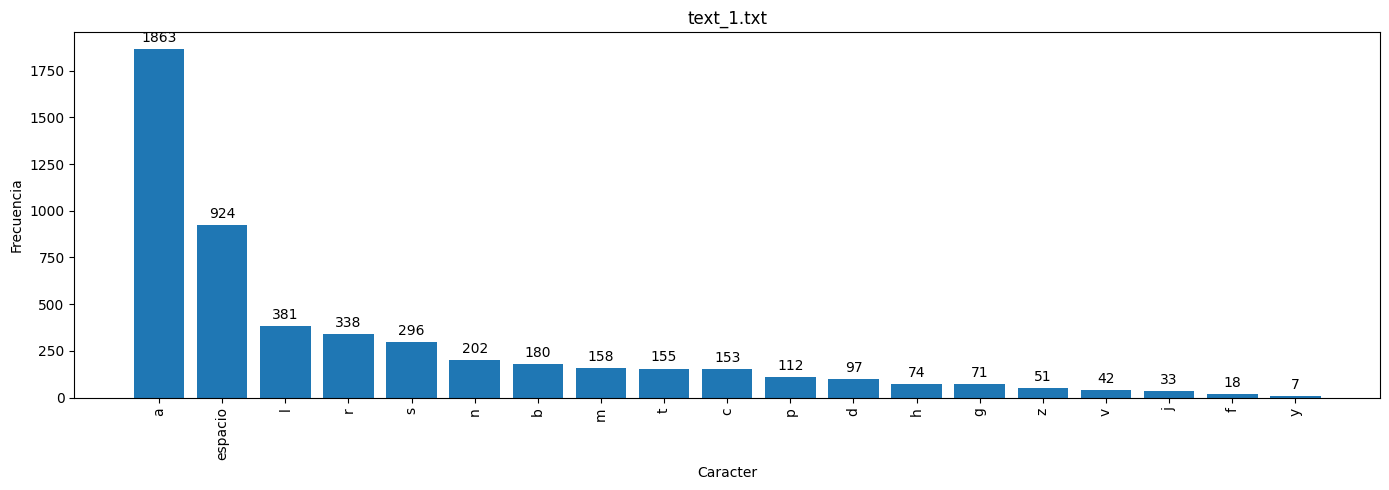

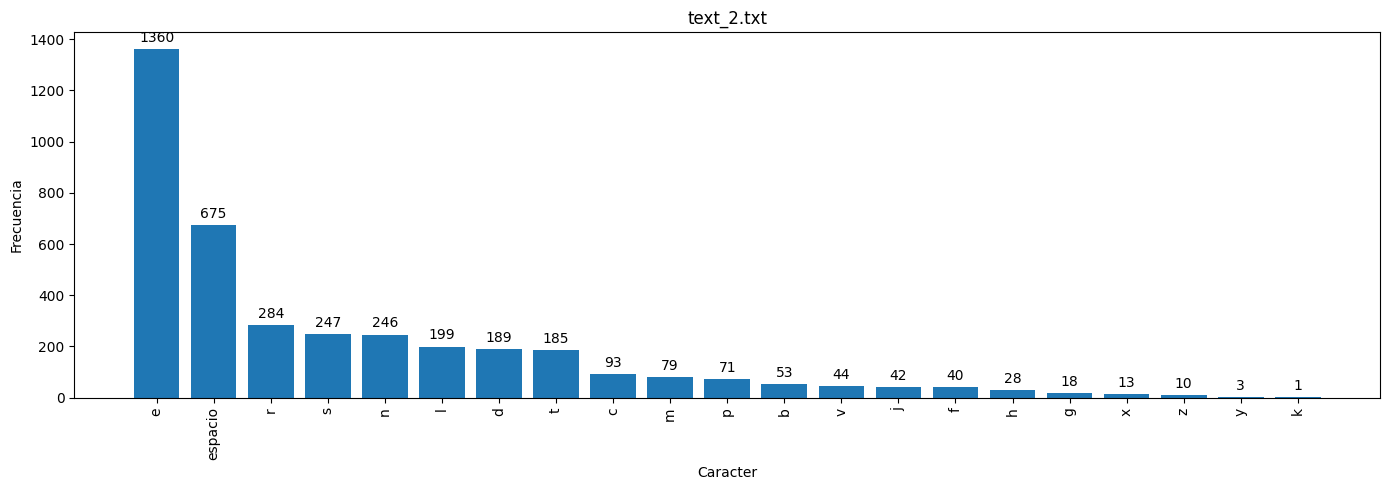

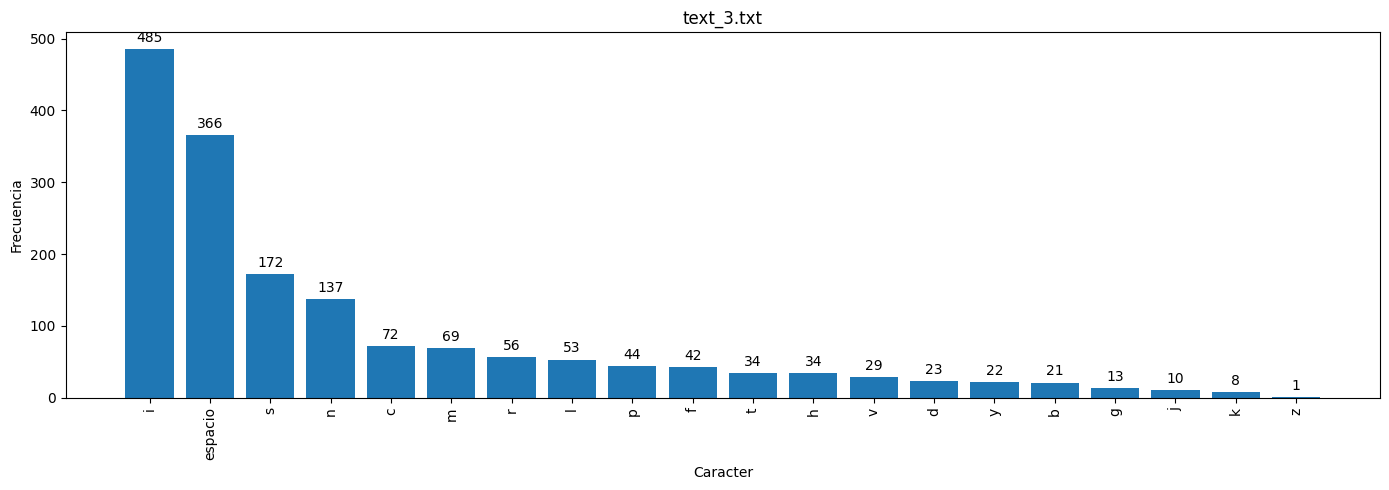

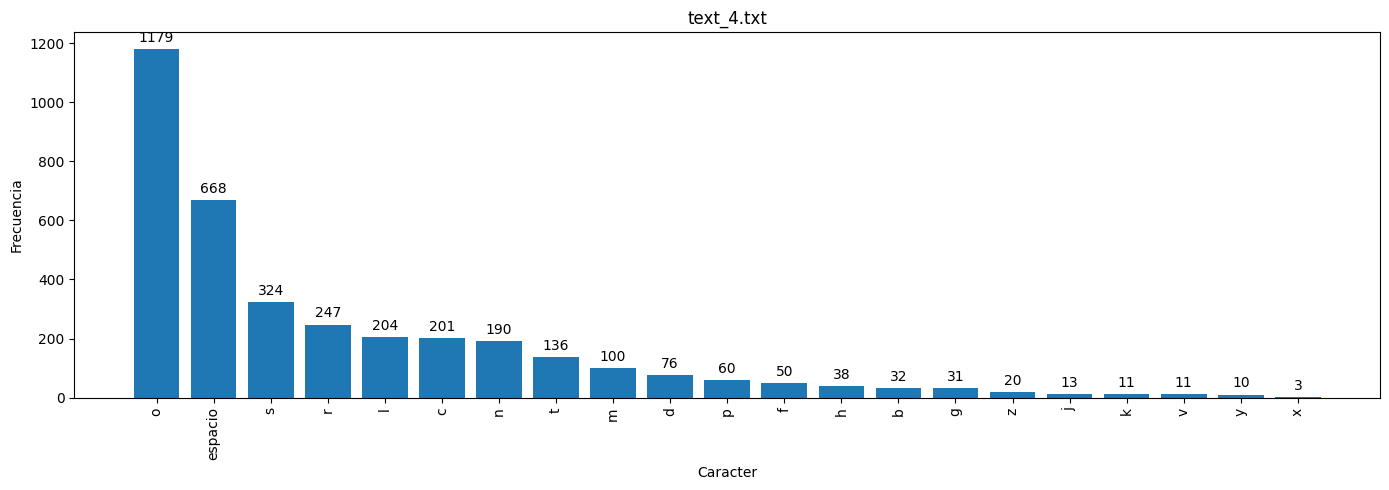

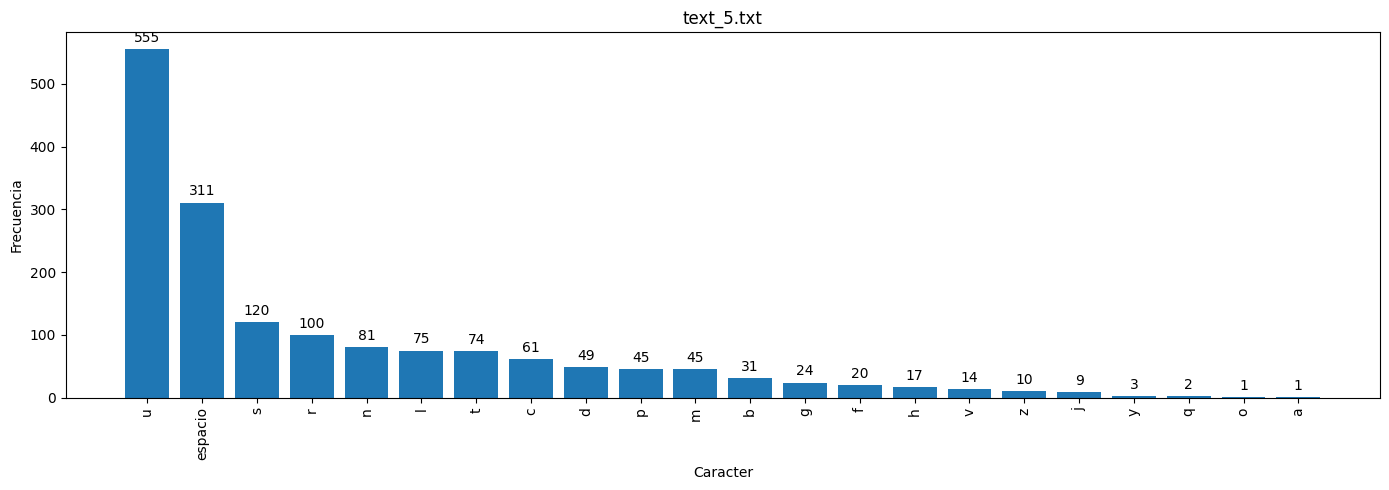

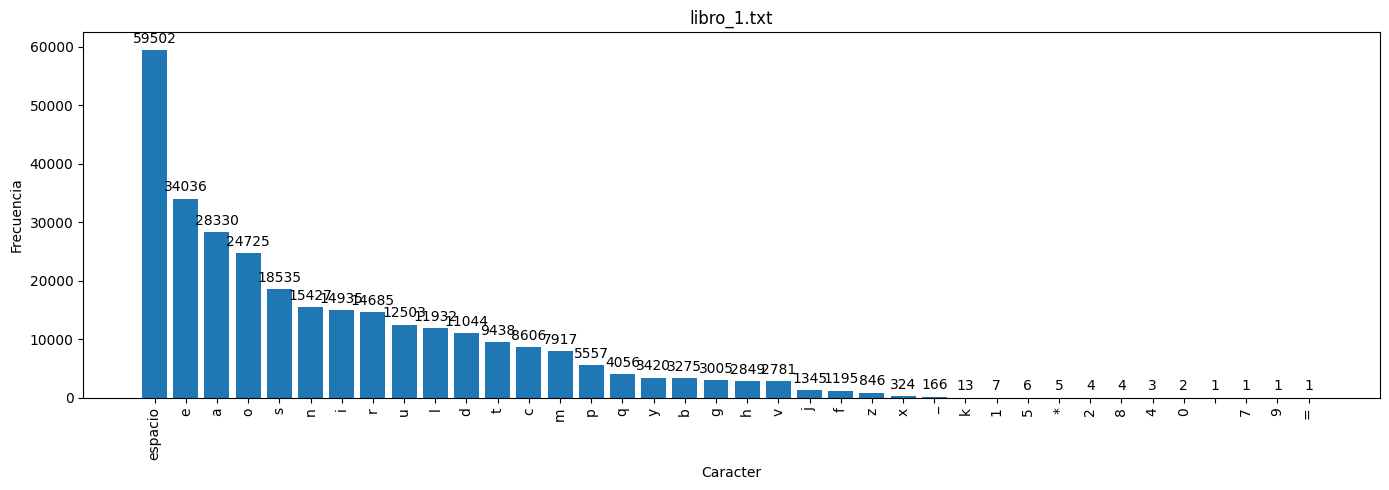

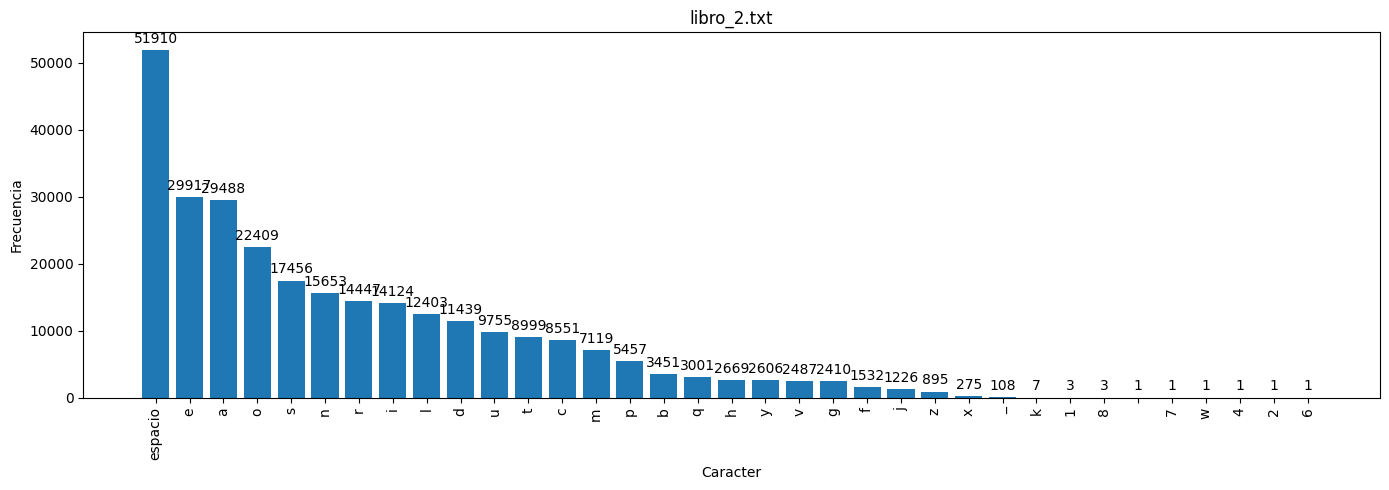

In [ ]:
for archivo in archivos:
  graficar_histograma(resultados, archivo)